In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import random
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Building Model
from keras.utils import plot_model
from tensorflow.keras import models
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.optimizers import legacy

# Training Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

# Data Processing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import array_to_img
from tensorflow.keras.preprocessing.image import load_img

In [3]:
# Global variables
SAVE = False
SEED = 111

# Setting seed for consistent results
tf.keras.utils.set_random_seed(SEED)
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Data Visualization updates
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = (16, 10)
plt.rcParams.update({'font.size': 14})

# Data Classifications
CLASS_TYPES = ['pituitary', 'notumor', 'meningioma', 'glioma']
N_TYPES = len(CLASS_TYPES)

In [5]:
import os

def get_data_labels(data_dir):
    paths = []
    labels = []

    for label in os.listdir(data_dir):
        label_path = os.path.join(data_dir, label)

        if os.path.isdir(label_path):
            for img in os.listdir(label_path):
                img_path = os.path.join(label_path, img)
                paths.append(img_path)
                labels.append(label)

    return paths, labels


In [7]:
USER_PATH = r"C:\\Users\\yogar\\Brain Tumor 2\\Dataset"
train_dir = USER_PATH + r'/Training/'
test_dir = USER_PATH + r'/Testing/'

# Getting data using above function
train_paths, train_labels = get_data_labels(train_dir)
test_paths, test_labels = get_data_labels(test_dir)

# Printing traing and testing sample sizes
print('Training')
print(f'Number of Paths: {len(train_paths)}')
print(f'Number of Labels: {len(train_labels)}')
print('\nTesting')
print(f'Number of Paths: {len(test_paths)}')
print(f'Number of Labels: {len(test_labels)}')

Training
Number of Paths: 5712
Number of Labels: 5712

Testing
Number of Paths: 1311
Number of Labels: 1311


x reshaped: (1, 150, 150, 3)


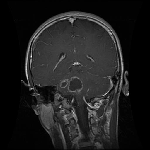

In [9]:
im = load_img(train_paths[3], target_size=(150, 150))
im = img_to_array(im)

# Reshape it to (1, 150, 150, 3)
im = np.expand_dims(im, axis=0)
print(f'x reshaped: {im.shape}')

# normilzation tensor
im /= np.max(im) # ~ np.max(img_tensor)

# Convert the array back to the image format
im = array_to_img(im[0])
display(im)

In [11]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [13]:
def show_images(image_paths, labels, im_size=350, figsize=(13,10), index_list=None):
    
    if index_list is None:
        index_list = np.random.choice(len(image_paths), 12, replace=False)

    rows = 3
    cols = 4

    plt.figure(figsize=figsize)

    for i, idx in enumerate(index_list):
        img = cv2.imread(image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (im_size, im_size))

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(labels[idx])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


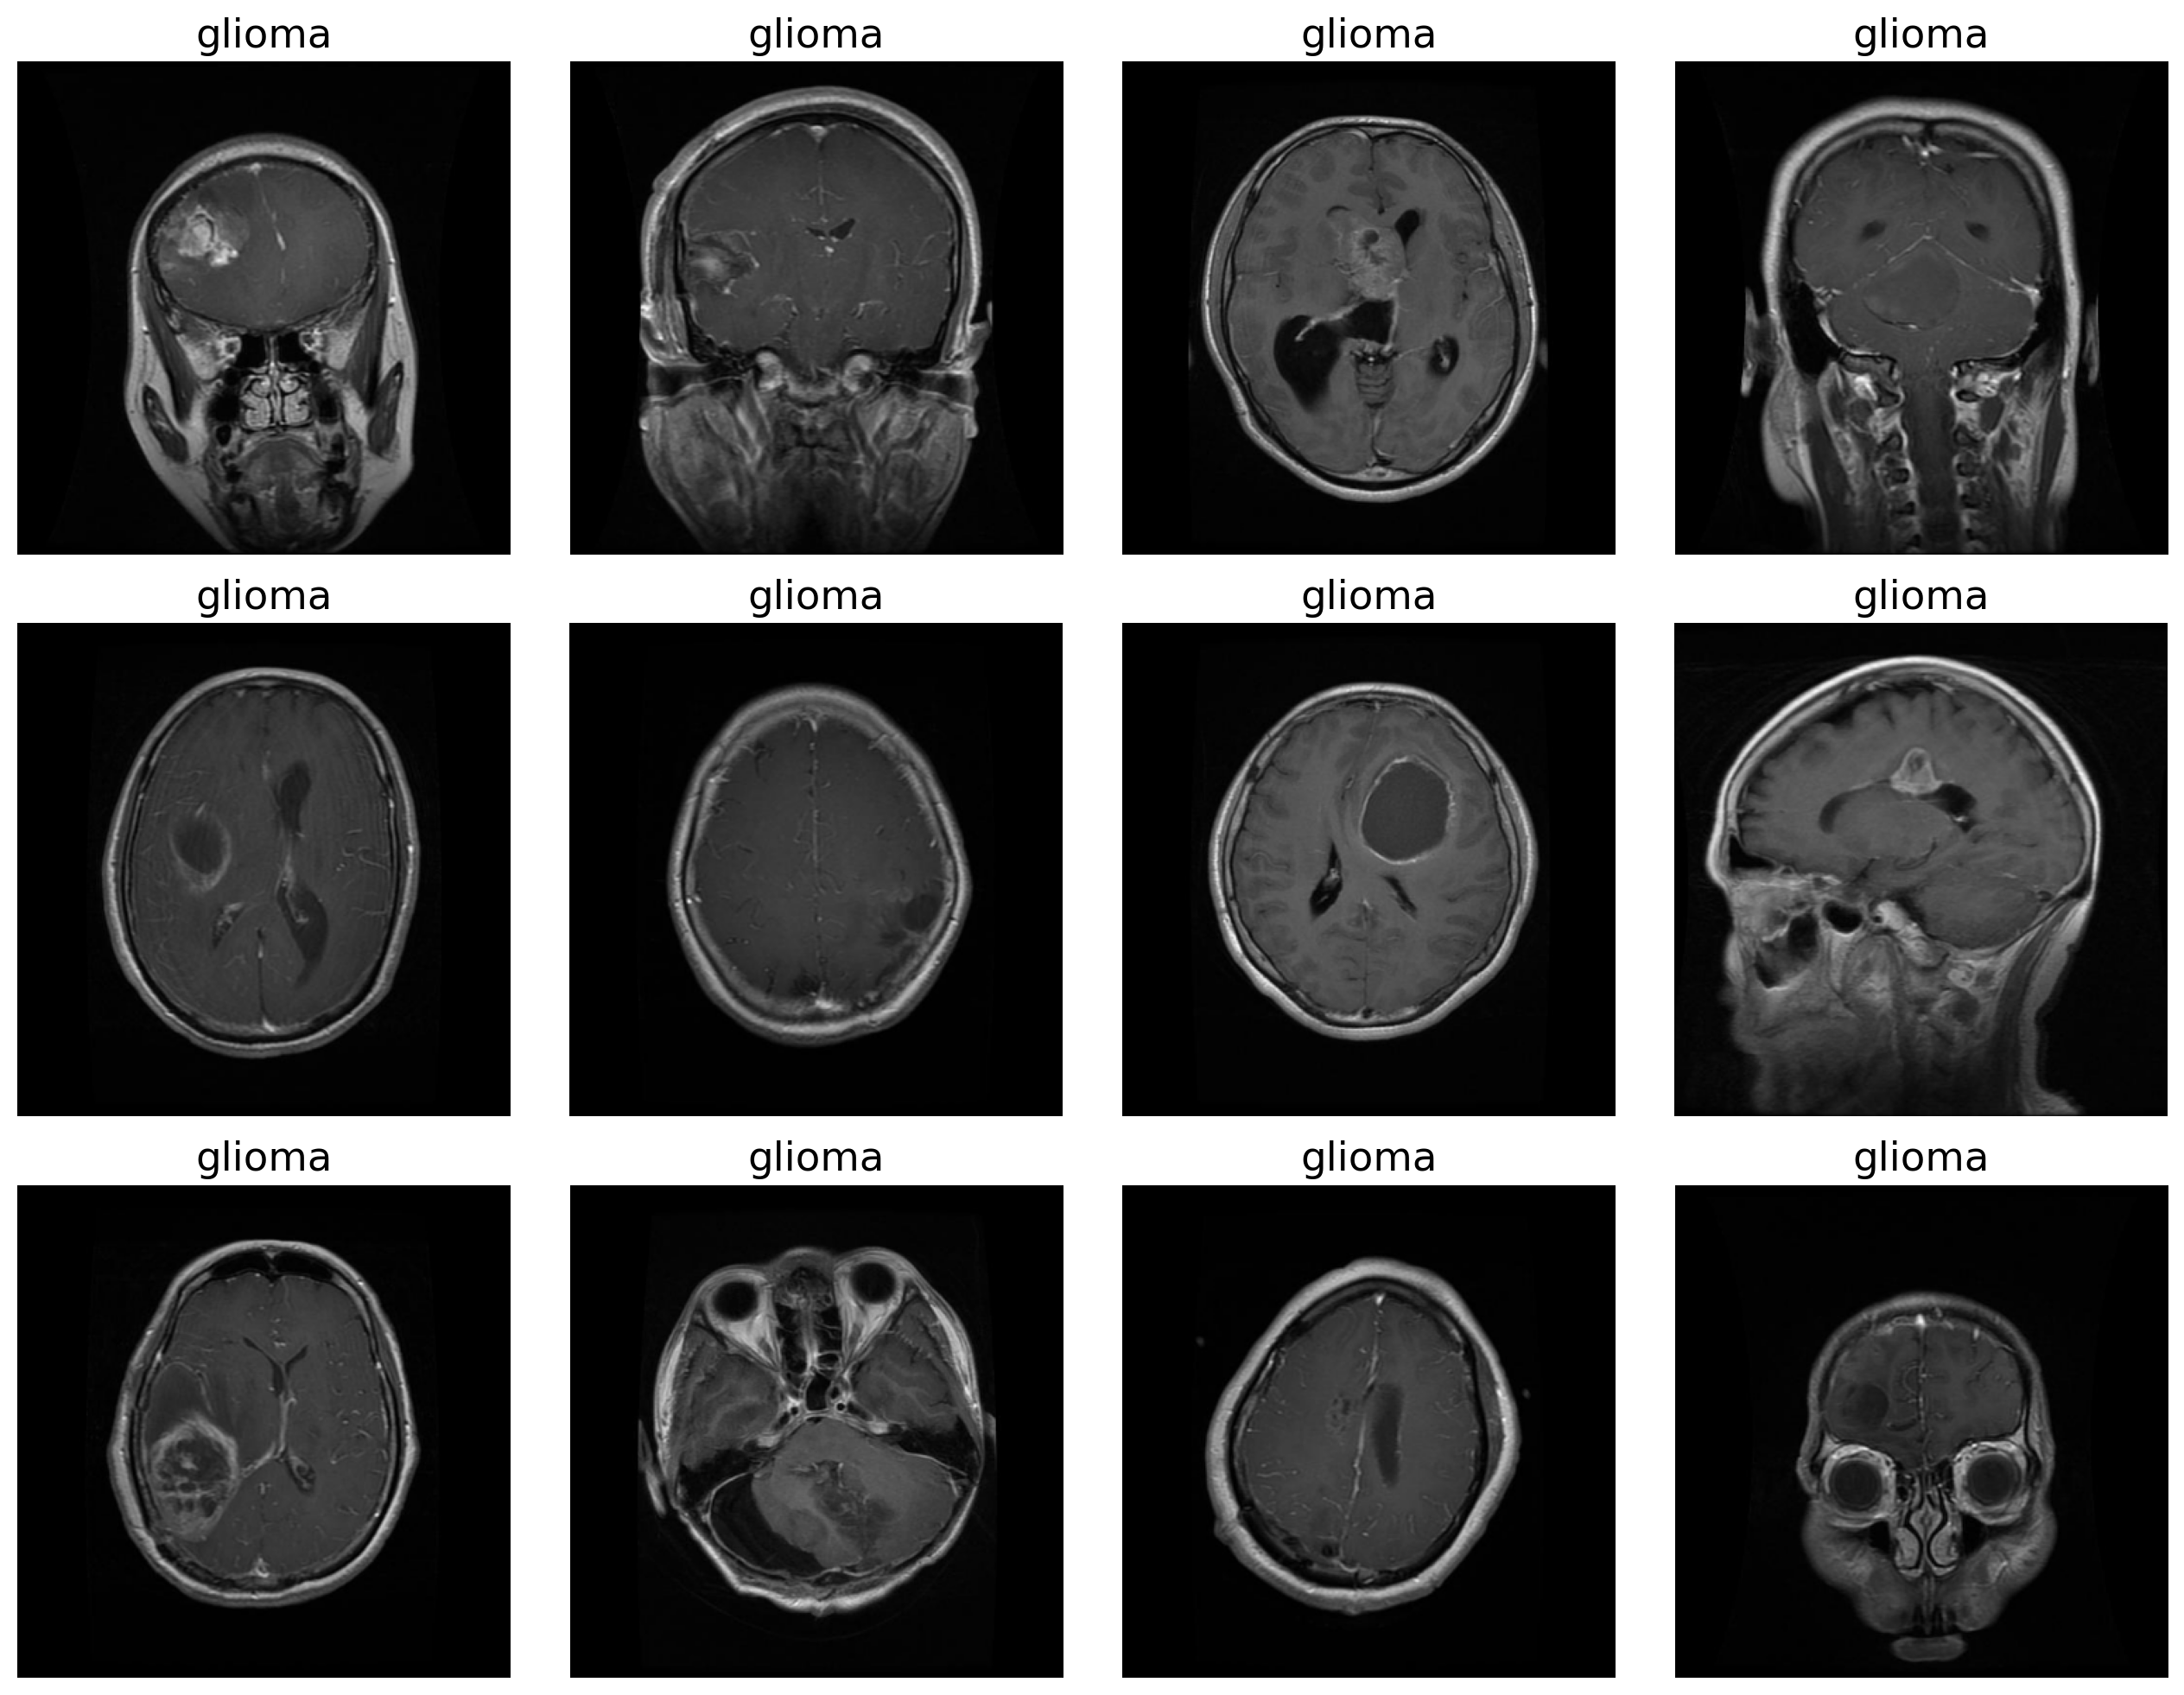

In [15]:
show_images(train_paths, train_labels, im_size=350, figsize=(13,10),
            index_list=[0, 94, 235, 17,
                        61, 324, 55, 45,
                        374, 65, 391, 488])


In [ ]:
# Image size
image_size = (150, 150)

# Training batch size
batch_size = 32

In [19]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=10,
                                   brightness_range=(0.85, 1.15),
                                   width_shift_range=0.002,
                                   height_shift_range=0.002,
                                   shear_range=12.5,
                                   zoom_range=0,
                                   horizontal_flip=True,
                                   vertical_flip=False,
                                   fill_mode="nearest")


# applying the generator to training data with constant seed
train_generator = train_datagen.flow_from_directory(train_dir,
                                                    target_size=image_size,
                                                    batch_size=batch_size,
                                                    class_mode="categorical",
                                                    seed=SEED)

# No augmentation of the test data, just rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

# applying the generator to testing data with constant seed
test_generator = test_datagen.flow_from_directory(test_dir,
                                                  target_size=image_size,
                                                  batch_size=batch_size,
                                                  class_mode="categorical",
                                                  shuffle=False,
                                                  seed=SEED)

Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [21]:
class_indices_train = train_generator.class_indices
class_indices_train_list = list(train_generator.class_indices.keys())


# Displaying categorical types
print("Categorical types for the training data:")
print(class_indices_train)

Categorical types for the training data:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [23]:
import matplotlib.pyplot as plt
import numpy as np

In [25]:
def show_ImageDataGenerator(datagen, num_samples=5, figsize=(12.5, 8), save=False):
    """
    Visualize augmented images from an ImageDataGenerator
    """

    # Create a dummy image (MRI-like placeholder)
    sample_img = np.random.rand(1, 224, 224, 3)

    augmented_iter = datagen.flow(sample_img, batch_size=1)

    plt.figure(figsize=figsize)

    for i in range(num_samples):
        aug_img = next(augmented_iter)[0]

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(aug_img)
        plt.axis("off")
        plt.title(f"Aug {i+1}")

    plt.tight_layout()

    if save:
        plt.savefig("ImageDataGenerator_Augmentations.png", dpi=300)

    plt.show()


In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)


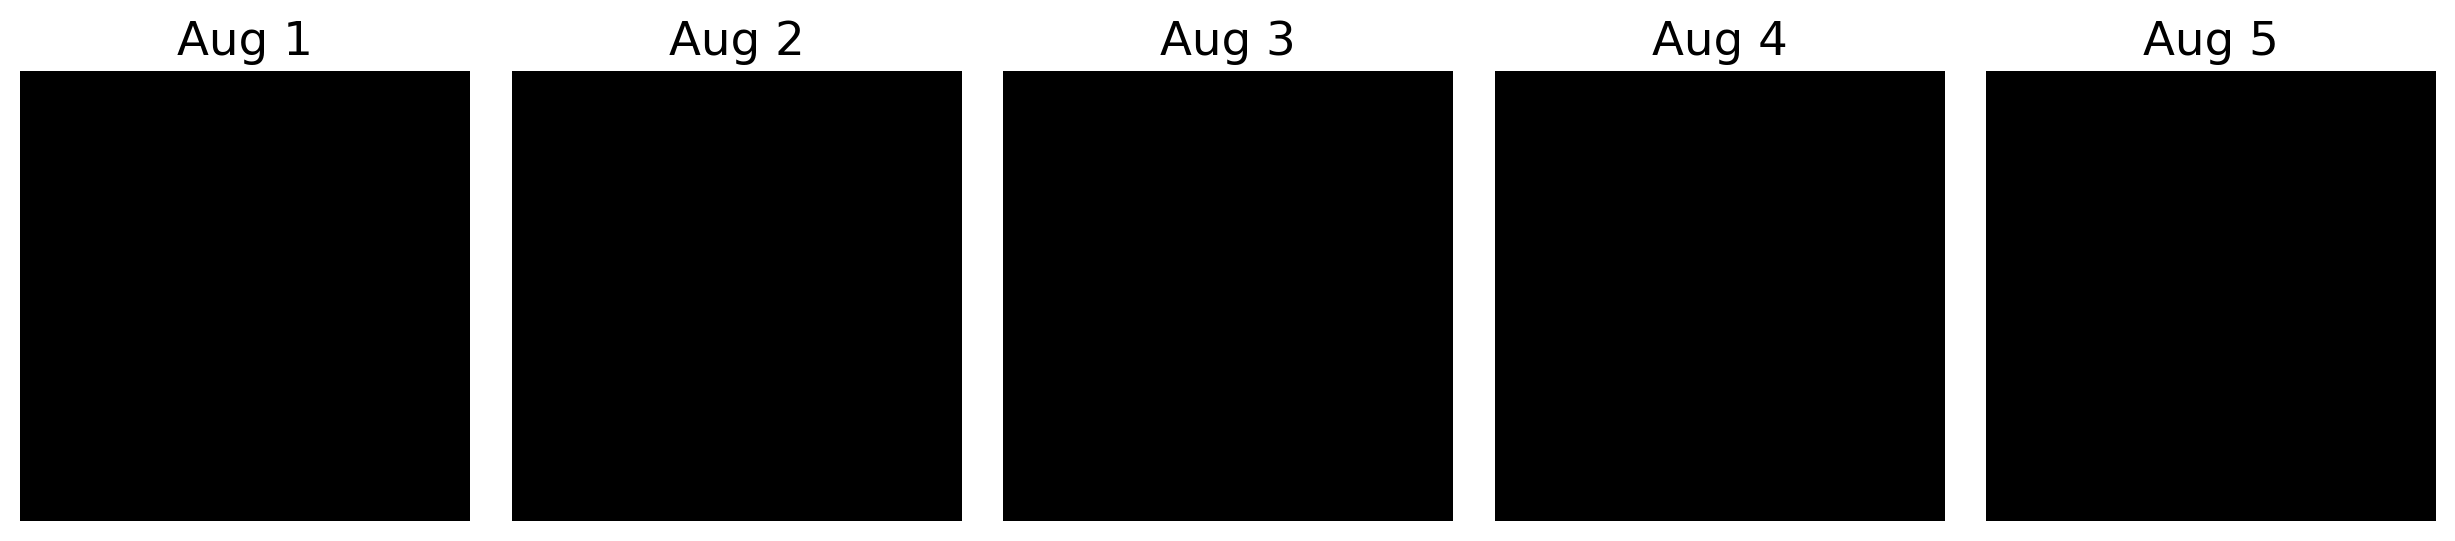

In [29]:
show_ImageDataGenerator(train_datagen, num_samples=5, figsize=(12.5, 8), save=SAVE)

In [31]:
image_shape = (image_size[0], image_size[1], 3)

# Training epochs
epochs = 40

# Steps per epoch
steps_per_epoch = train_generator.samples // batch_size

# Validation steps
validation_steps = test_generator.samples // batch_size

print(f'Image shape: {image_shape}')
print(f'Epochs: {epochs}')
print(f'Batch size: {batch_size}')
print(f'Steps Per Epoch: {steps_per_epoch}')
print(f'Validation steps: {validation_steps}')

Image shape: (150, 150, 3)
Epochs: 40
Batch size: 32
Steps Per Epoch: 178
Validation steps: 40


In [33]:
# Define the model architecture
model_1 = models.Sequential()

# Convolutional layer 1
model_1.add(Conv2D(32, (4, 4), activation="relu", input_shape=image_shape))
model_1.add(MaxPooling2D(pool_size=(3, 3)))

# Convolutional layer 2
model_1.add(Conv2D(64, (4, 4), activation="relu"))
model_1.add(MaxPooling2D(pool_size=(3, 3)))

# Convolutional layer 3
model_1.add(Conv2D(128, (4, 4), activation="relu"))
model_1.add(MaxPooling2D(pool_size=(3, 3)))

# Convolutional layer 4
model_1.add(Conv2D(128, (4, 4), activation="relu"))
model_1.add(Flatten())

# Full connect layers
model_1.add(Dense(512, activation="relu"))
model_1.add(Dropout(0.5, seed=SEED))
model_1.add(Dense(N_TYPES, activation="softmax"))

model_1.summary()

C:\Users\yogar\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 147, 147, 32)   │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 1, 1, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 495,972 (1.89 MB)

 Trainable params: 495,972 (1.89 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

EarlyStopping(monitor='val_loss', min_delta=0, patience=0, verbose=0, mode='auto', baseline=None, restore_best_weights=False, start_from_epoch=0)
ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=10, verbose=0, mode='auto', min_delta=0.0001, cooldown=0, min_lr=0)

In [37]:
model = models.Sequential([
    
    # Convolutional layer 1
    Conv2D(32, (4, 4), activation="relu", input_shape=image_shape),
    MaxPooling2D(pool_size=(3, 3)),

    # Convolutional layer 2
    Conv2D(64, (4, 4), activation="relu"),
    MaxPooling2D(pool_size=(3, 3)),

    # Convolutional layer 3
    Conv2D(128, (4, 4), activation="relu"),
    MaxPooling2D(pool_size=(3, 3)),

    # Convolutional layer 4
    Conv2D(128, (4, 4), activation="relu"),
    Flatten(),

    # Full connect layers
    Dense(512, activation="relu"),
    Dropout(0.5, seed=SEED),
    Dense(N_TYPES, activation="softmax")
])

model.summary()
from tensorflow.keras.optimizers import Adam
optimizer = Adam(
    learning_rate=0.001,
    beta_1=0.869,
    beta_2=0.995
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 147, 147, 32)   │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 1, 1, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 495,972 (1.89 MB)

 Trainable params: 495,972 (1.89 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model_es = EarlyStopping(monitor='loss', min_delta=1e-9, patience=8, verbose=True)
model_rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, verbose=True)

# Training the model
history = model.fit(train_generator,
                    steps_per_epoch=steps_per_epoch,
                    epochs=epochs,
                    validation_data=test_generator,
                    validation_steps=validation_steps,
                    callbacks=[model_es, model_rlr])

C:\Users\yogar\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
178/178 ━━━━━━━━━━━━━━━━━━━━ 74s 406ms/step - accuracy: 0.4633 - loss: 1.1017 - val_accuracy: 0.7461 - val_loss: 0.6666 - learning_rate: 0.0010
Epoch 2/40
  1/178 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - accuracy: 0.7500 - loss: 0.4638

C:\Users\yogar\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7500 - loss: 0.4638 - val_accuracy: 0.7500 - val_loss: 0.6453 - learning_rate: 0.0010
Epoch 3/40
178/178 ━━━━━━━━━━━━━━━━━━━━ 74s 416ms/step - accuracy: 0.7681 - loss: 0.5592 - val_accuracy: 0.7719 - val_loss: 0.5328 - learning_rate: 0.0010
Epoch 4/40
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7188 - loss: 0.6175 - val_accuracy: 0.7836 - val_loss: 0.5304 - learning_rate: 0.0010
Epoch 5/40
178/178 ━━━━━━━━━━━━━━━━━━━━ 72s 401ms/step - accuracy: 0.8270 - loss: 0.4355 - val_accuracy: 0.7867 - val_loss: 0.5401 - learning_rate: 0.0010
Epoch 6/40
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9375 - loss: 0.2722 - val_accuracy: 0.8117 - val_loss: 0.4656 - learning_rate: 0.0010
Epoch 7/40
178/178 ━━━━━━━━━━━━━━━━━━━━ 70s 394ms/step - accuracy: 0.8652 - loss: 0.3468 - val_accuracy: 0.8758 - val_loss: 0.3210 - learning_rate: 0.0010
Epoch 8/40
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7500 - loss: 0.4005 

In [41]:
loss, accuracy = model.evaluate(test_generator, steps=test_generator.samples//batch_size)
print(f"Test Loss: {loss:0.5f}")
print(f"Test Accuracy: {accuracy:0.5f}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.9853 - loss: 0.0575
Test Loss: 0.05269
Test Accuracy: 0.98750


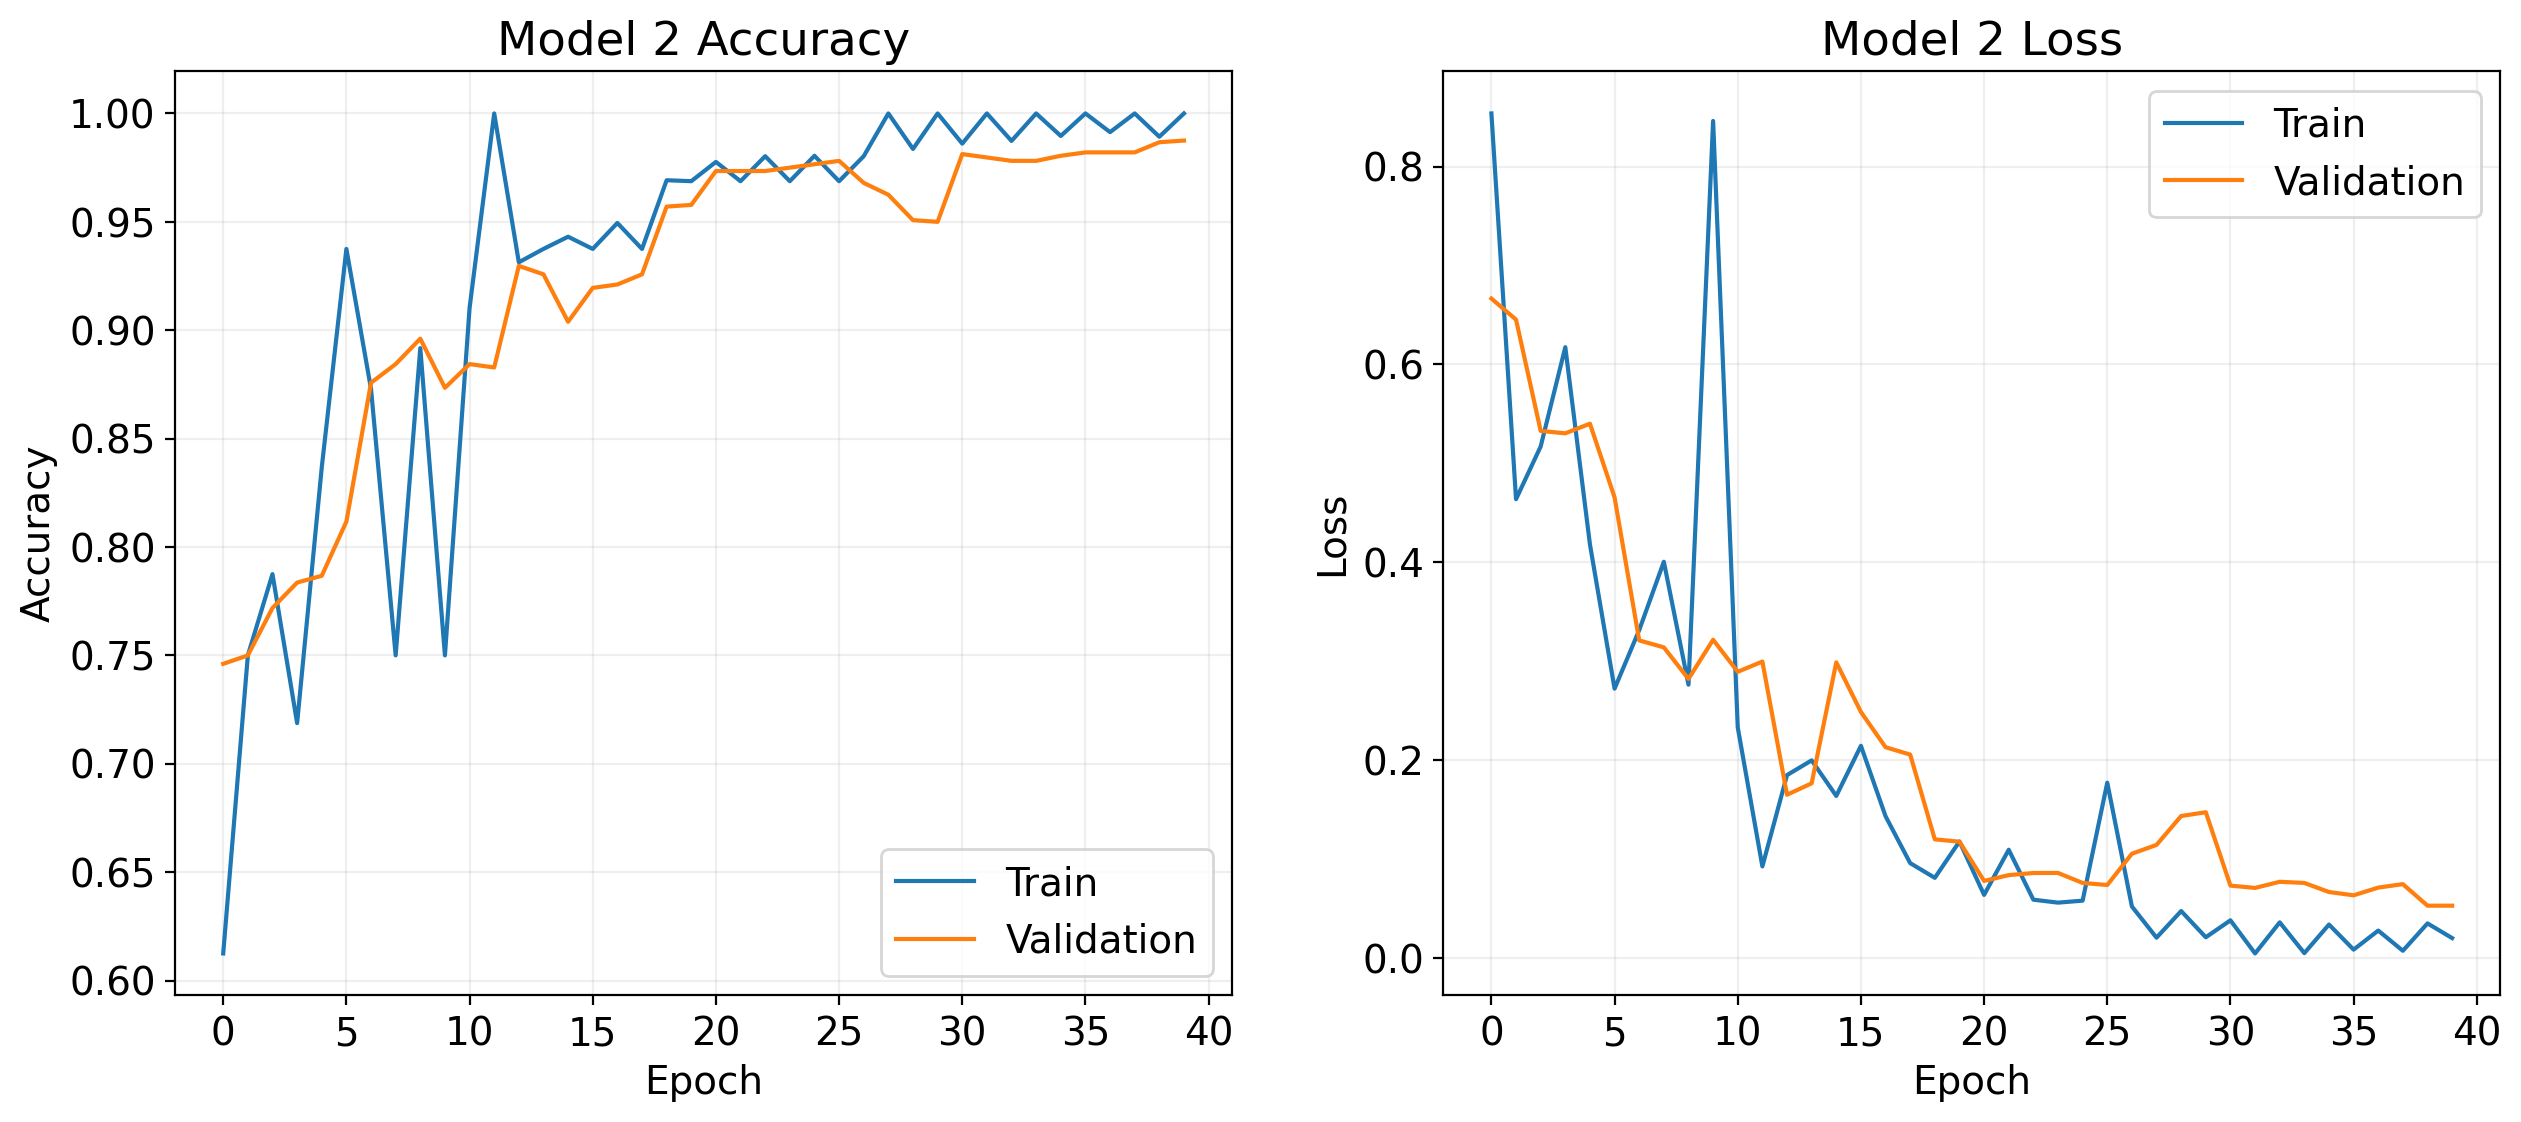

In [43]:
_, ax = plt.subplots(ncols=2, figsize=(15, 6))

# Plot the training and validation accuracy over epochs
ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Model 2 Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend(['Train', 'Validation'])
ax[0].grid(alpha=0.2)

# Plot the training and validation loss over epochs
ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Model 2 Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend(['Train', 'Validation'])
ax[1].grid(alpha=0.2)

plt.show()

41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step


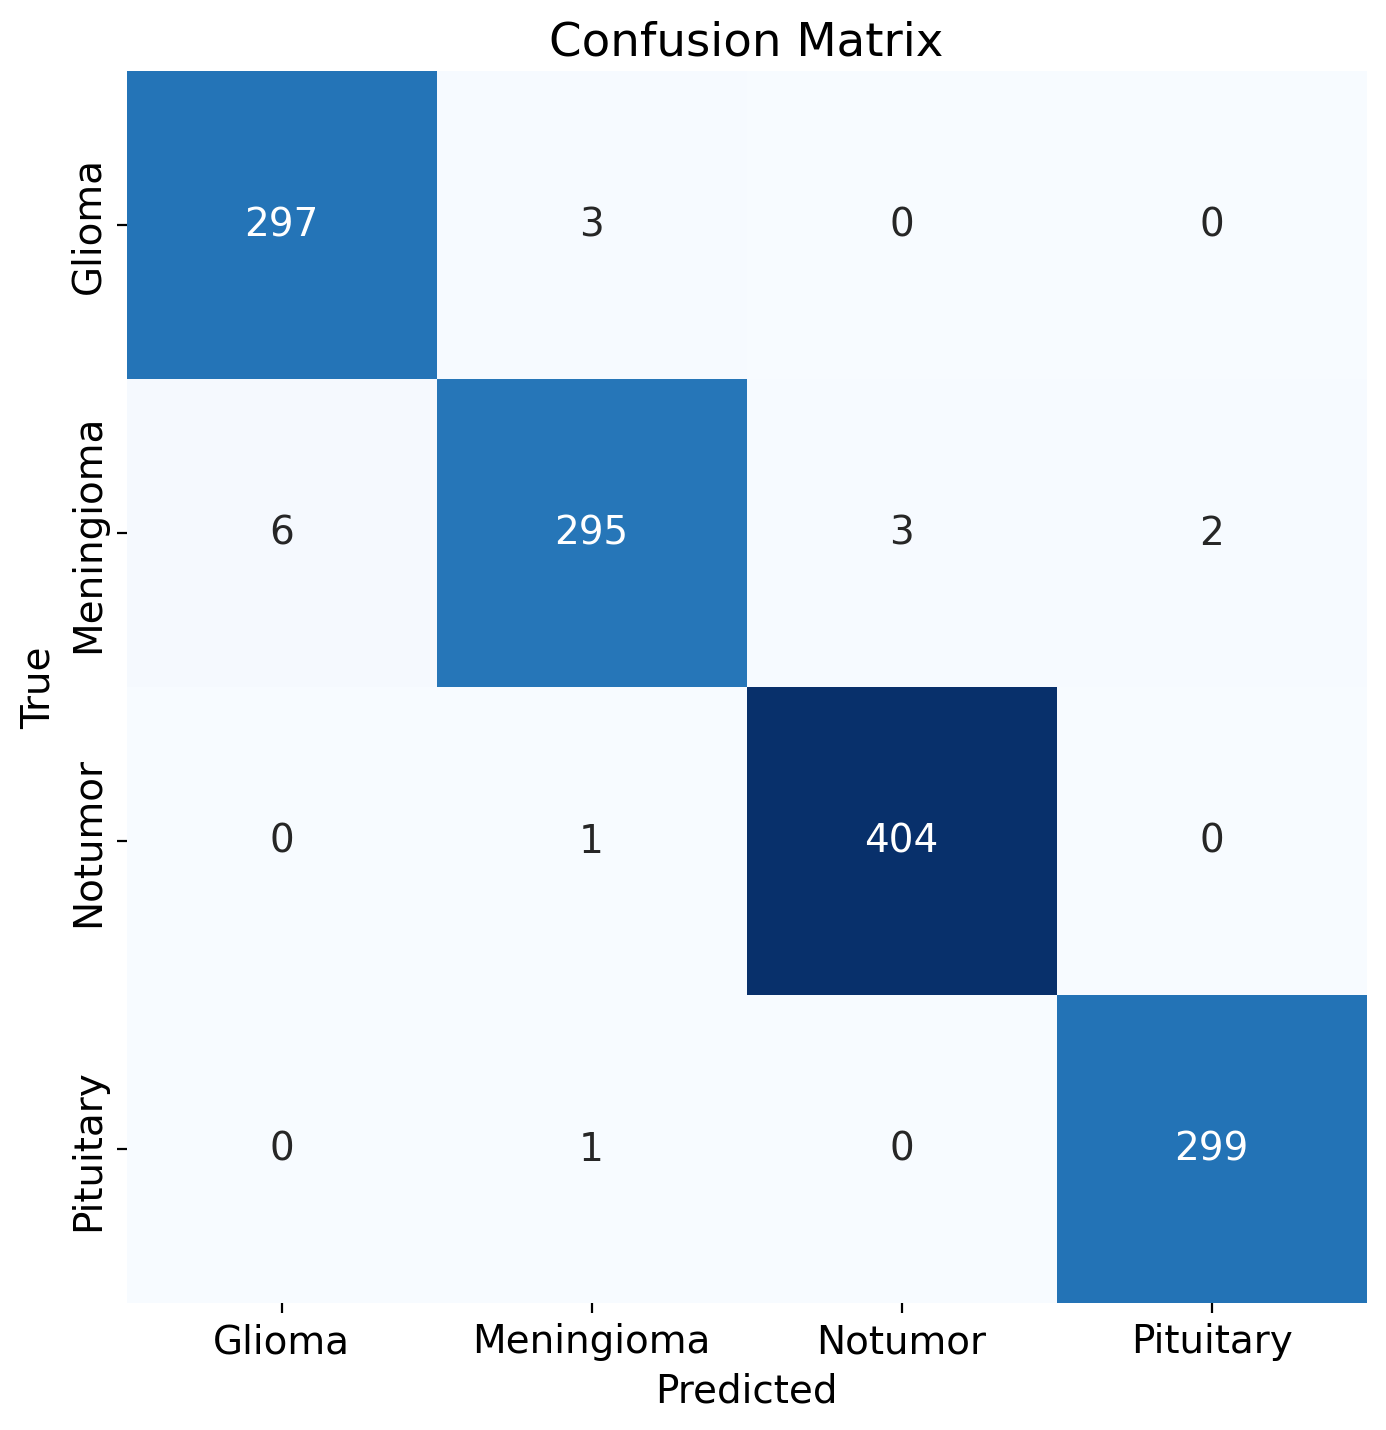

In [45]:
from sklearn.metrics import confusion_matrix

def CM(CNN_model, test_generator, categories):
    test_generator.reset()
    preds = CNN_model.predict(test_generator)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_generator.classes
    return confusion_matrix(y_true, y_pred)

confusion_matrix = CM(CNN_model=model, test_generator=test_generator, categories=class_indices_train_list)

plt.figure(figsize=(8,8))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(ticks=np.arange(N_TYPES) + 0.5,
           labels=[name.title() for name in class_indices_train_list], ha='center')
plt.yticks(ticks=np.arange(N_TYPES) + 0.5, 
           labels=[name.title() for name in class_indices_train_list], va='center')
plt.show()

In [47]:
import numpy as np
import pandas as pd

def calculate_metrics(cm, categories):
    metrics = []

    total_samples = np.sum(cm)

    for i, class_name in enumerate(categories):
        TP = cm[i, i]
        FP = np.sum(cm[:, i]) - TP
        FN = np.sum(cm[i, :]) - TP
        TN = total_samples - (TP + FP + FN)

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1_score  = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        accuracy  = (TP + TN) / total_samples

        metrics.append([
            class_name.title(),
            round(accuracy, 4),
            round(precision, 4),
            round(recall, 4),
            round(f1_score, 4)
        ])

    return pd.DataFrame(
        metrics,
        columns=["Class", "Accuracy", "Precision", "Recall", "F1-Score"]
    )


In [49]:
metrics_df = calculate_metrics(confusion_matrix, categories=class_indices_train_list)
metrics_df

,Class,Accuracy,Precision,Recall,F1-Score
0,Glioma,0.9931,0.9802,0.9900,0.9851
1,Meningioma,0.9878,0.9833,0.9641,0.9736
2,Notumor,0.9969,0.9926,0.9975,0.9951
3,Pituitary,0.9977,0.9934,0.9967,0.9950


In [51]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def plot_sample_predictions(
    model,
    test_generator,
    categories,
    test_dir,
    num_samples=9,
    figsize=(13, 12)
):
    # Reset generator
    test_generator.reset()

    # Predict
    predictions = model.predict(test_generator)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_generator.classes

    # File paths
    file_paths = test_generator.filepaths

    # Select random samples
    indices = np.random.choice(len(file_paths), num_samples, replace=False)

    plt.figure(figsize=figsize)

    for i, idx in enumerate(indices):
        img_path = os.path.join(test_dir, file_paths[idx])
        img = load_img(img_path, target_size=test_generator.target_size)
        img_array = img_to_array(img) / 255.0

        true_label = categories[y_true[idx]].title()
        pred_label = categories[y_pred[idx]].title()

        plt.subplot(int(np.sqrt(num_samples)), int(np.sqrt(num_samples)), i + 1)
        plt.imshow(img_array)
        plt.axis("off")

        color = "green" if true_label == pred_label else "red"
        plt.title(
            f"True: {true_label}\nPred: {pred_label}",
            color=color,
            fontsize=10
        )

    plt.tight_layout()
    plt.show()


41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step


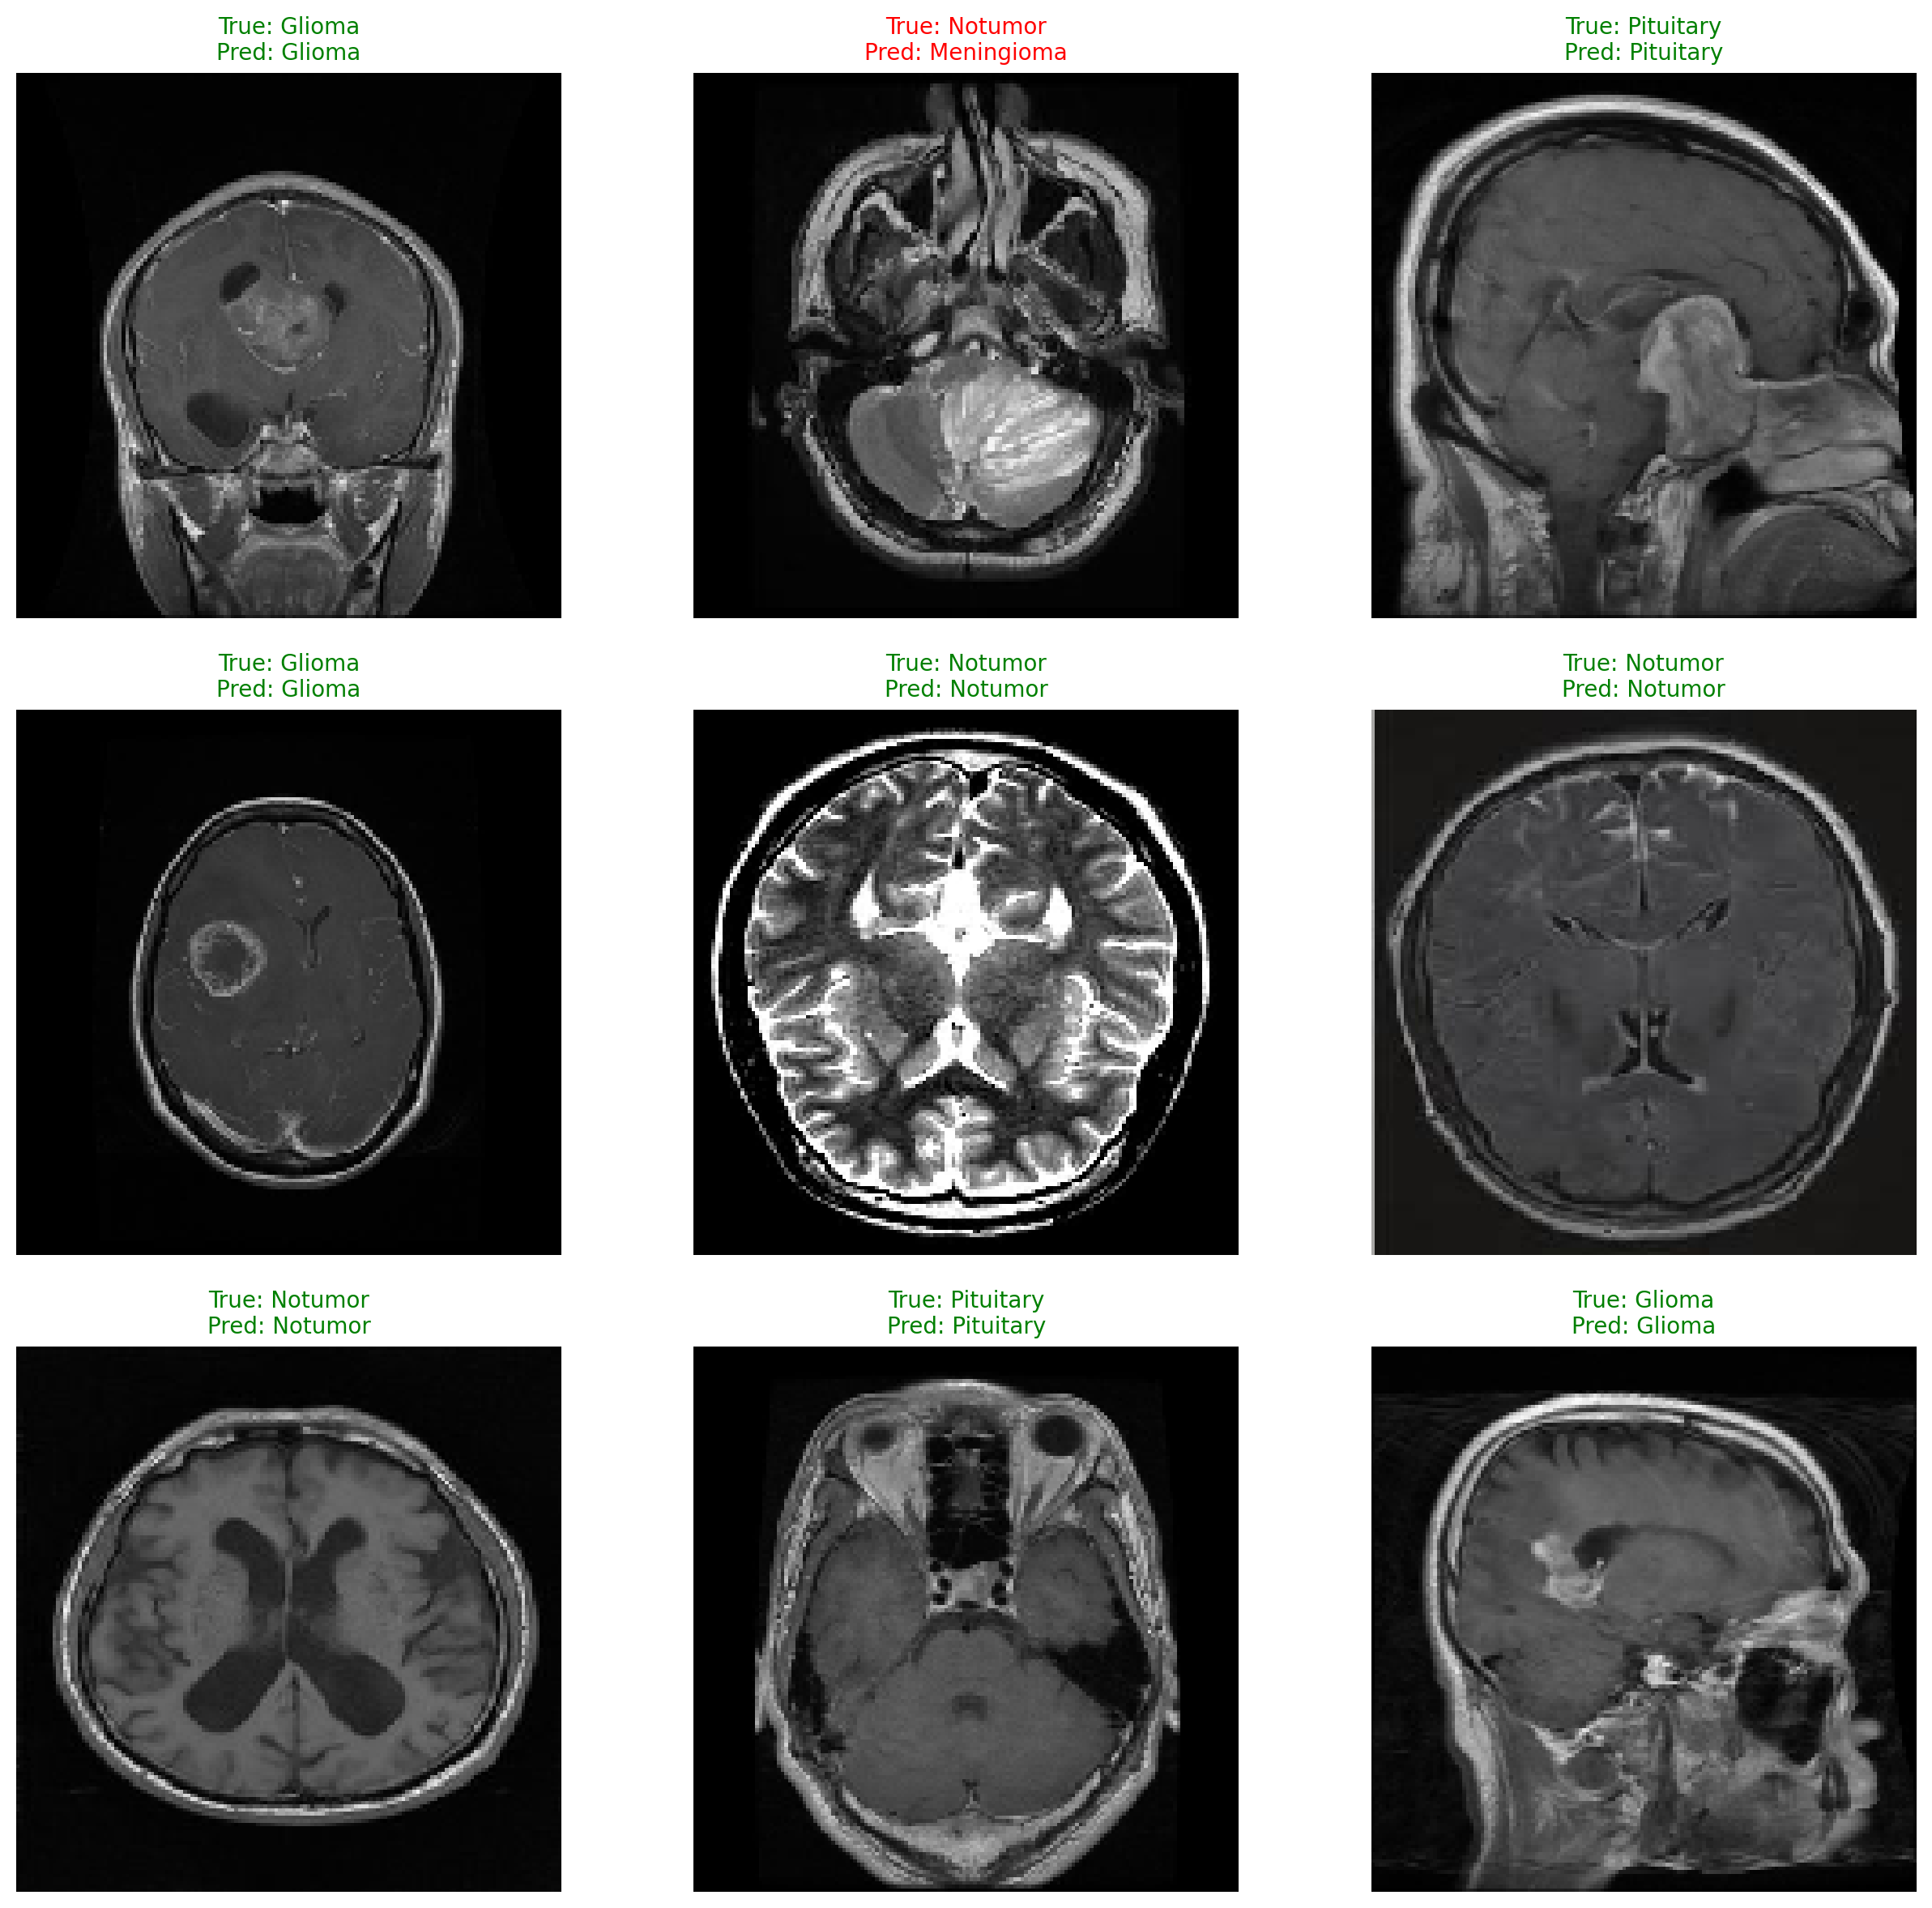

In [53]:
plot_sample_predictions(model=model, 
                        test_generator=test_generator, 
                        categories=class_indices_train_list,
                        test_dir=test_dir, 
                        num_samples=9,
                        figsize=(13, 12))

Class name of the first image: glioma
Shape (1, 150, 150, 3)


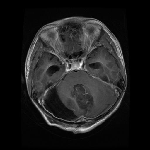

In [55]:
# Get the next batch from the test generator
batch_images, batch_labels = next(test_generator)

# Extract the first image from the batch
image, label = batch_images[0], batch_labels[0]
image_tensor = np.expand_dims(image, axis=0)

# Get the class indices from the test generator
class_indices = test_generator.class_indices

# Convert the one-hot encoded label to the class name
label_name = [k for k, v in class_indices.items() if np.argmax(label) == v][0]

# Display the class name
print(f"Class name of the first image: {label_name}")
print(f'Shape {image_tensor.shape}')
array_to_img(image_tensor[0])

In [57]:
_ = model.predict(image_tensor)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.models import Model

def plot_channel_activation_maps(
    model,
    image,
    N=5,
    save=False,
    layer_name=None,
    save_dir="activation_maps"
):
    # Ensure batch dimension
    if image.ndim == 3:
        image = np.expand_dims(image, axis=0)

    # Force model to be called (creates inbound nodes)
    _ = model(image)

    # Find first Conv layer if not specified
    if layer_name is None:
        for layer in model.layers:
            if "conv" in layer.name.lower():
                layer_name = layer.name
                break

    if layer_name is None:
        raise ValueError("No convolutional layer found in the model.")

    # ✅ CRITICAL FIX: use model.inputs (plural)
    activation_model = Model(
        inputs=model.inputs,
        outputs=model.get_layer(layer_name).output
    )

    # Get activations
    activations = activation_model.predict(image)[0]

    N = min(N, activations.shape[-1])

    plt.figure(figsize=(N * 3, 3))
    for i in range(N):
        plt.subplot(1, N, i + 1)
        plt.imshow(activations[:, :, i], cmap="viridis")
        plt.axis("off")
        plt.title(f"Ch {i+1}")

    plt.suptitle(f"Activation Maps ({layer_name})", fontsize=14)
    plt.tight_layout()

    if save:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{layer_name}_activations.png")
        plt.savefig(path, dpi=300)
        print(f"Saved to: {path}")

    plt.show()


In [61]:
print(model.input_shape)

(None, 150, 150, 3)


In [63]:
image_path = test_generator.filepaths[0]
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

img = load_img(image_path, target_size=(150, 150))
image_tensor = img_to_array(img) / 255.0
image_tensor = np.expand_dims(image_tensor, axis=0)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


C:\Users\yogar\anaconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_67']
Received: inputs=Tensor(shape=(1, 150, 150, 3))
  warnings.warn(msg)


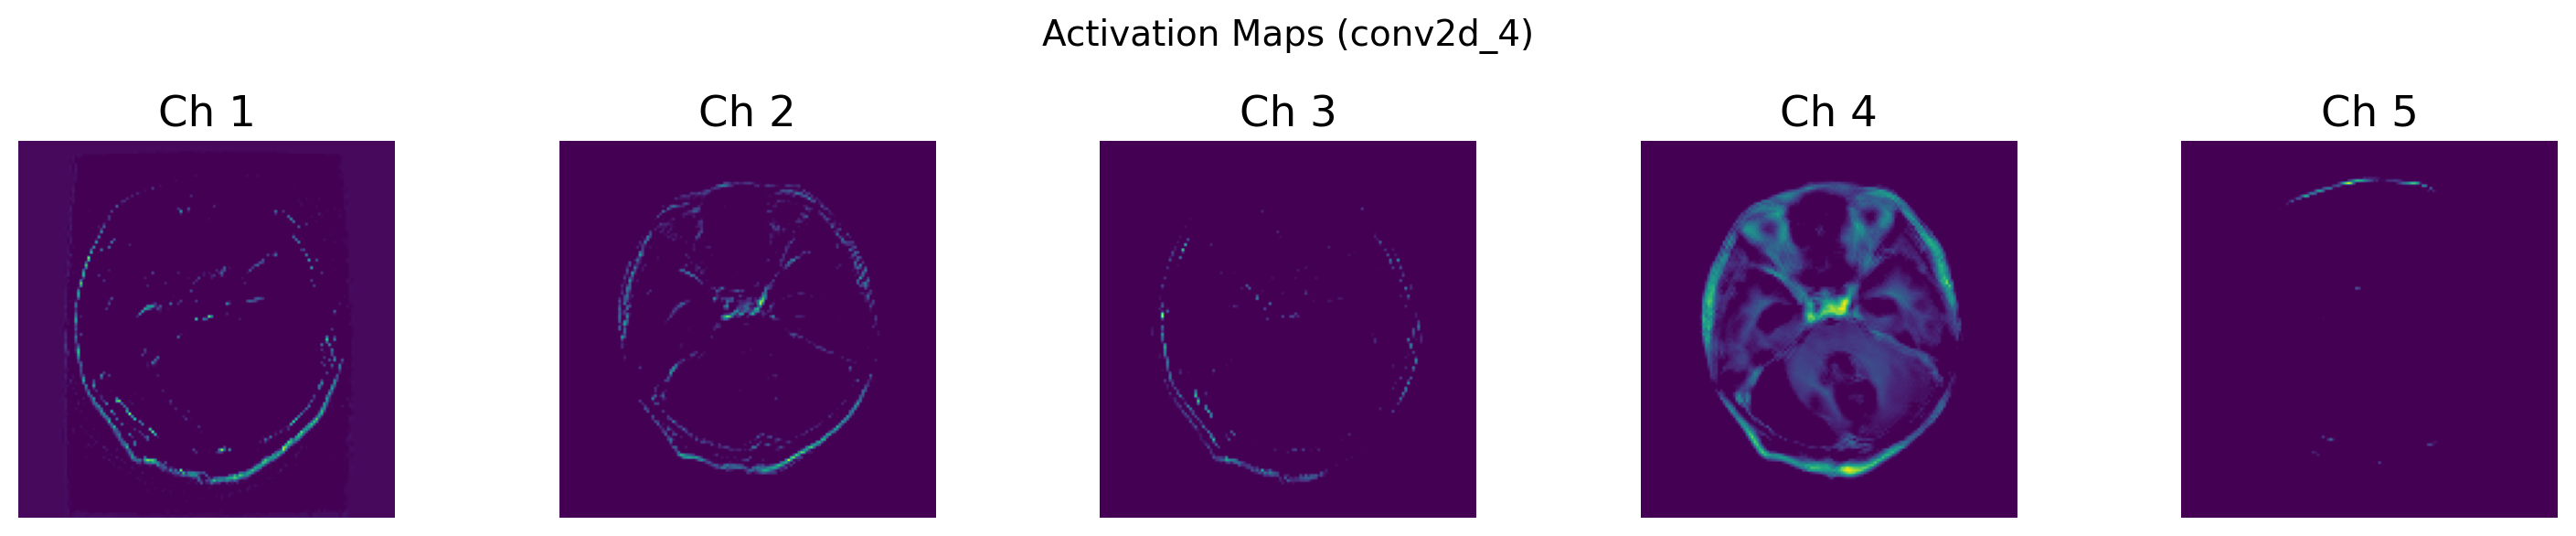

In [65]:
plot_channel_activation_maps(
    model=model,
    image=image_tensor,
    N=5,
    save=SAVE
)


In [67]:
import numpy as np
import matplotlib.pyplot as plt
import random
from tensorflow.keras.preprocessing.image import load_img

def visualize_misclassified_images(
    model,
    test_generator,
    class_indices,
    max_images=9,
    figsize=(13, 12)
):
    # Reverse class_indices: index → class name
    idx_to_class = {v: k for k, v in class_indices.items()}

    # Reset generator and predict
    test_generator.reset()
    preds = model.predict(test_generator)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_generator.classes

    # Find misclassified indices
    misclassified = np.where(y_pred != y_true)[0]

    if len(misclassified) == 0:
        print("🎉 No misclassified images found!")
        return

    # Randomly select images
    num_images = min(max_images, len(misclassified))
    selected = random.sample(list(misclassified), num_images)

    plt.figure(figsize=figsize)

    for i, idx in enumerate(selected):
        img_path = test_generator.filepaths[idx]
        img = load_img(img_path, target_size=test_generator.target_size)

        true_label = idx_to_class[y_true[idx]].title()
        pred_label = idx_to_class[y_pred[idx]].title()

        plt.subplot(int(np.sqrt(num_images)), int(np.sqrt(num_images)), i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"True: {true_label}\nPred: {pred_label}",
            color="red",
            fontsize=10
        )

    plt.suptitle("Misclassified Test Images", fontsize=16)
    plt.tight_layout()
    plt.show()


41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step


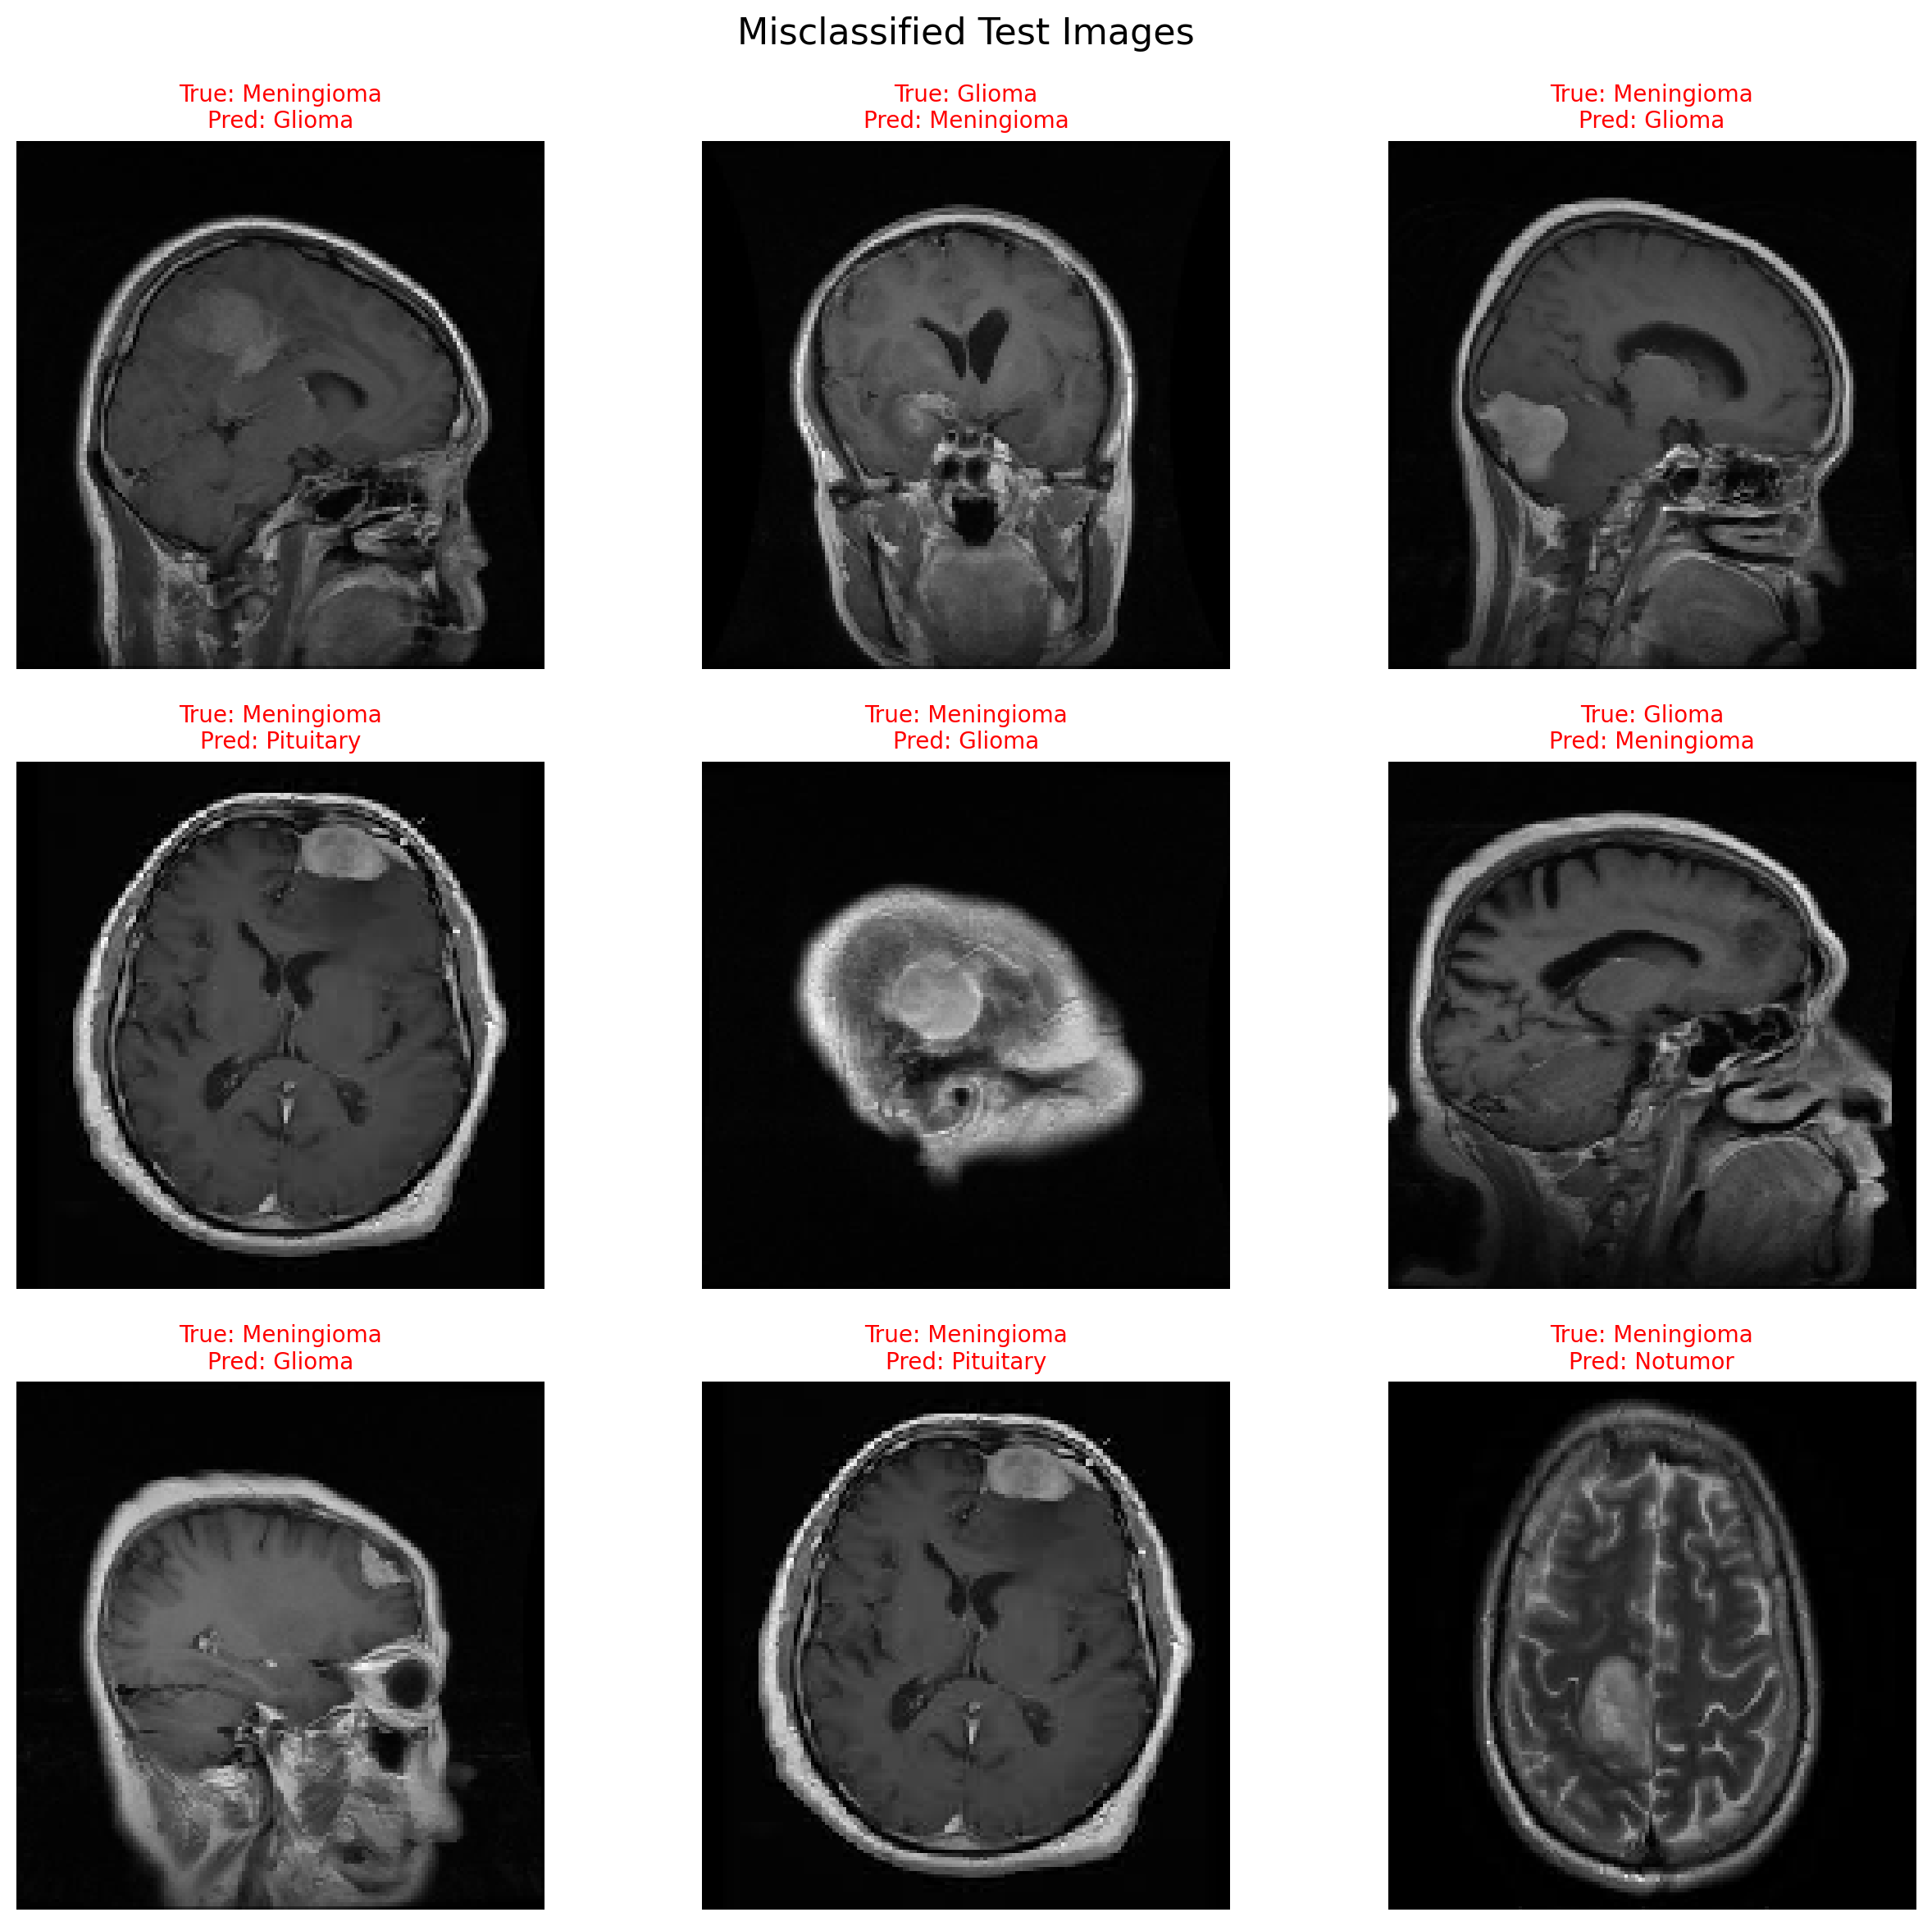

In [69]:
visualize_misclassified_images(model, test_generator, test_generator.class_indices)

In [113]:
print("Model input shape:", model.input_shape)


Model input shape: (None, 150, 150, 3)


In [125]:
CLASSES = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary"
]


In [127]:
def predict_tumor(image):
    import numpy as np
    import cv2

    try:
        if image is None:
            return "❌ No image uploaded"

        # Read expected input from model
        _, H, W, C = model.input_shape

        image = np.array(image)

        # Convert channels automatically
        if C == 1 and image.ndim == 3:
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        if C == 3 and image.ndim == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

        # Resize EXACTLY to model size
        image = cv2.resize(image, (W, H))

        # Normalize
        image = image.astype("float32") / 255.0

        # Add channel if needed
        if C == 1:
            image = np.expand_dims(image, axis=-1)

        # Add batch dimension
        image = np.expand_dims(image, axis=0)

        # Final safety check
        assert image.shape[1:] == model.input_shape[1:], \
            f"Input mismatch: {image.shape} vs {model.input_shape}"

        # Predict
        preds = model.predict(image)
        class_idx = int(np.argmax(preds))
        confidence = float(np.max(preds))

        return f"Tumor Type: {CLASSES[class_idx]}\nConfidence: {confidence:.2f}"

    except Exception as e:
        return f"❌ ERROR:\n{str(e)}"


In [129]:
import gradio as gr

gr.Interface(
    fn=predict_tumor,
    inputs=gr.Image(type="numpy", label="Upload Brain MRI"),
    outputs=gr.Textbox(label="Prediction"),
    title="🧠 Brain Tumor Classification"
).launch(inline=True)


* Running on local URL:  http://127.0.0.1:7868

To create a public link, set `share=True` in `launch()`.
